# M2A5 - Métricas de Desempenho

> **Resumo:** Acurácia pode MENTIR! Aqui aprendemos métricas mais robustas: precisão, recall, F1-score. Cada uma olha pra um aspecto diferente do modelo.

> 📝 Exemplo clássico: um modelo que sempre diz "saudável" tem 95% de acurácia se 95% dos exames são normais. Mas é INÚTIL!

**Estrutura do notebook:**

- Conceitos (acurácia, precisão, recall, F1, matriz de confusão)
- Prática: calculando métricas na mão e com sklearn
- ✅ Atividades Complementares

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

In [2]:
# Dataset e modelo
digits = datasets.load_digits()
X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=42
)

svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)

## Métricas Básicas

In [3]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Acurácia:  {acc*100:.1f}%")
print(f"Precisão:  {prec*100:.1f}%")
print(f"Recall:    {rec*100:.1f}%")
print(f"F1-Score:  {f1*100:.1f}%")

Acurácia:  98.6%
Precisão:  98.6%
Recall:    98.6%
F1-Score:  98.6%


> 📝 **O que cada métrica responde:**
> - **Acurácia:** "De todas as previsões, quantas acertei?"
> - **Precisão:** "Das que eu disse que são classe X, quantas realmente são?"
> - **Recall:** "Das que realmente são classe X, quantas eu encontrei?"
> - **F1-Score:** Média harmônica entre precisão e recall — equilíbrio!

## Relatório Completo

In [4]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        34
           4       1.00      1.00      1.00        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       0.97      0.97      0.97        34
           8       1.00      0.97      0.98        30
           9       0.95      0.95      0.95        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



## Matriz de Confusão

A diagonal = acertos. Fora da diagonal = erros. Cada célula (i, j) mostra quantas imagens da classe i foram classificadas como classe j.

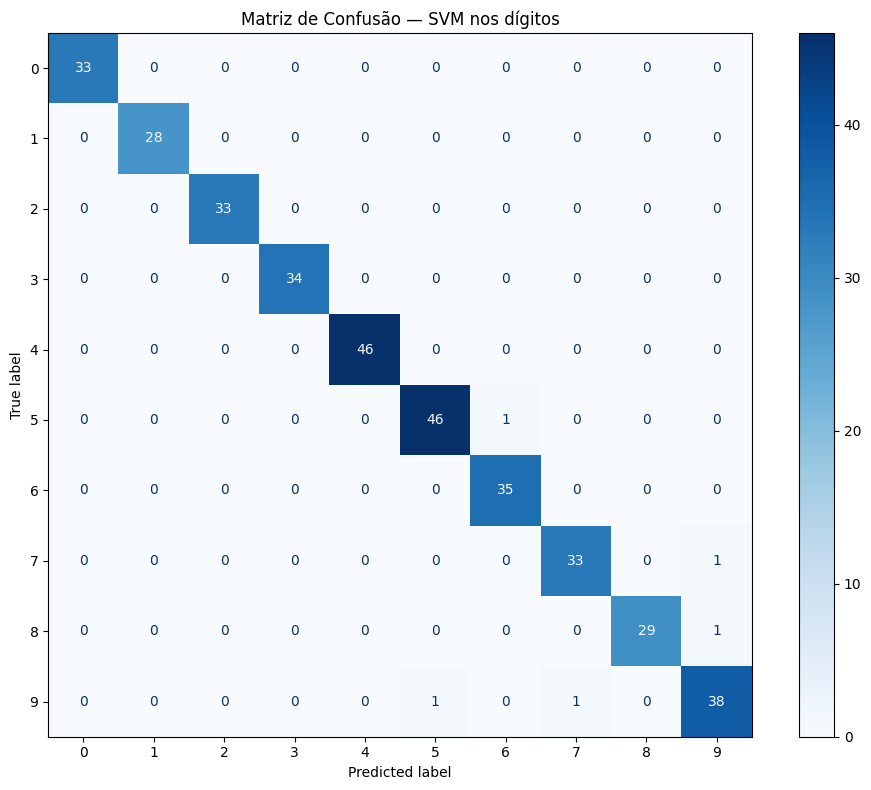

Matriz de Confusão (Textual):
[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 34  0  0  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  0  0 46  1  0  0  0]
 [ 0  0  0  0  0  0 35  0  0  0]
 [ 0  0  0  0  0  0  0 33  0  1]
 [ 0  0  0  0  0  0  0  0 29  1]
 [ 0  0  0  0  0  1  0  1  0 38]]


In [5]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=digits.target_names)
disp.plot(cmap='Blues', ax=ax)
plt.title("Matriz de Confusão — SVM nos dígitos")
plt.tight_layout()
plt.show()

print("Matriz de Confusão (Textual):")
print(cm)

## ✅ Atividades Complementares

### Calculando métricas "na mão" (caso binário)

In [6]:
# Simulando um problema binário: dígito 5 vs resto
y_test_bin = (y_test == 5).astype(int)
y_pred_bin = (y_pred == 5).astype(int)

TP = np.sum((y_pred_bin == 1) & (y_test_bin == 1))
FP = np.sum((y_pred_bin == 1) & (y_test_bin == 0))
FN = np.sum((y_pred_bin == 0) & (y_test_bin == 1))
TN = np.sum((y_pred_bin == 0) & (y_test_bin == 0))

print(f"TP={TP}, FP={FP}, FN={FN}, TN={TN}")
print(f"Acurácia  = (TP+TN)/(total) = {(TP+TN)/(TP+FP+FN+TN)*100:.1f}%")
print(f"Precisão  = TP/(TP+FP)       = {TP/(TP+FP)*100:.1f}%" if TP+FP > 0 else "Precisão: N/A")
print(f"Recall    = TP/(TP+FN)       = {TP/(TP+FN)*100:.1f}%" if TP+FN > 0 else "Recall: N/A")

prec_manual = TP/(TP+FP) if TP+FP > 0 else 0
rec_manual = TP/(TP+FN) if TP+FN > 0 else 0
f1_manual = 2 * prec_manual * rec_manual / (prec_manual + rec_manual) if (prec_manual + rec_manual) > 0 else 0
print(f"F1-Score  = 2*P*R/(P+R)     = {f1_manual*100:.1f}%")

TP=46, FP=1, FN=1, TN=312
Acurácia  = (TP+TN)/(total) = 99.4%
Precisão  = TP/(TP+FP)       = 97.9%
Recall    = TP/(TP+FN)       = 97.9%
F1-Score  = 2*P*R/(P+R)     = 97.9%


> 📝 Entender essas fórmulas "na mão" é essencial pra interpretar resultados e escolher a métrica certa pro seu problema!